In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
from DataLoader import Raw_Data, Loader, Express_Data
from pathlib import Path

In [5]:
data_dir = Path("/mnt/Data1/Python_Projects/WebPages/Project-04-HamiAnalyzer/V1/hami_data")


In [11]:
reader = Raw_Data(data_dir)
loader = Loader(reader)
loader.fit("105001_2")
express = Express_Data()
express.fit(loader)

In [12]:
express.compressed_data

,date,message,from,to,to_email,from_id,to_id,matched
0,1404-06-22 10:59:00,<empty>,STUDENT,کارشناسی ناپیوسته_مهندسی حرفه ای معماری_یزد_4032,sf-105-40889-3-4032@iau.ir,<empty>,6de5b81d-3985-4de3-845d-336ea219ca7e,True
1,1404-06-23 13:24:00,با سلام لطفا جهت اقدام لازم,کارشناسی ناپیوسته_مهندسی حرفه ای معماری_یزد_4032,محمود روحپرور,336216@iau.ir,6de5b81d-3985-4de3-845d-336ea219ca7e,ab89d904-d19e-41e8-a642-5da2dd919693,True
2,1404-06-23 13:24:00,موضوع: 'درخواست اینترنت دانشجویی'\nبا سلام لطف...,کارشناسی ناپیوسته_مهندسی حرفه ای معماری_یزد_4032,محمود روحپرور,336216@iau.ir,6de5b81d-3985-4de3-845d-336ea219ca7e,ab89d904-d19e-41e8-a642-5da2dd919693,True
3,1404-06-23 13:52:00,موضوع: 'پاسخ: درخواست اینترنت دانشجویی'\nبا سل...,محمود روحپرور,کارشناسی ناپیوسته_مهندسی حرفه ای معماری_یزد_4032,sf-105-40889-3-4032@iau.ir,ab89d904-d19e-41e8-a642-5da2dd919693,c335878a-66d4-47ae-8bf5-261175adc32d,True
4,1404-06-24 08:53:00,<empty>,کارشناسی ناپیوسته_مهندسی حرفه ای معماری_یزد_4032,yasamin ghotbizadeh,4710834660@iau.ir,c335878a-66d4-47ae-8bf5-261175adc32d,0dce7c22-36f8-41e4-adc2-8ac99e16f232,True
5,1500-01-01 00:00:00,احتراما درخواست دارم برای درس طرح معماری 3 افز...,Not in workflow,Not in workflow,Not in workflow,Not in workflow,Not in workflow,False


In [2]:
from main import HamiWorks

hami = HamiWorks()


In [3]:
hami.analyzer(hami)

TypeError: HamiWorks.analyzer() missing 3 required positional arguments: 'extra_data_file_path', 'plot_folder', and 'csv_folder'

522
526


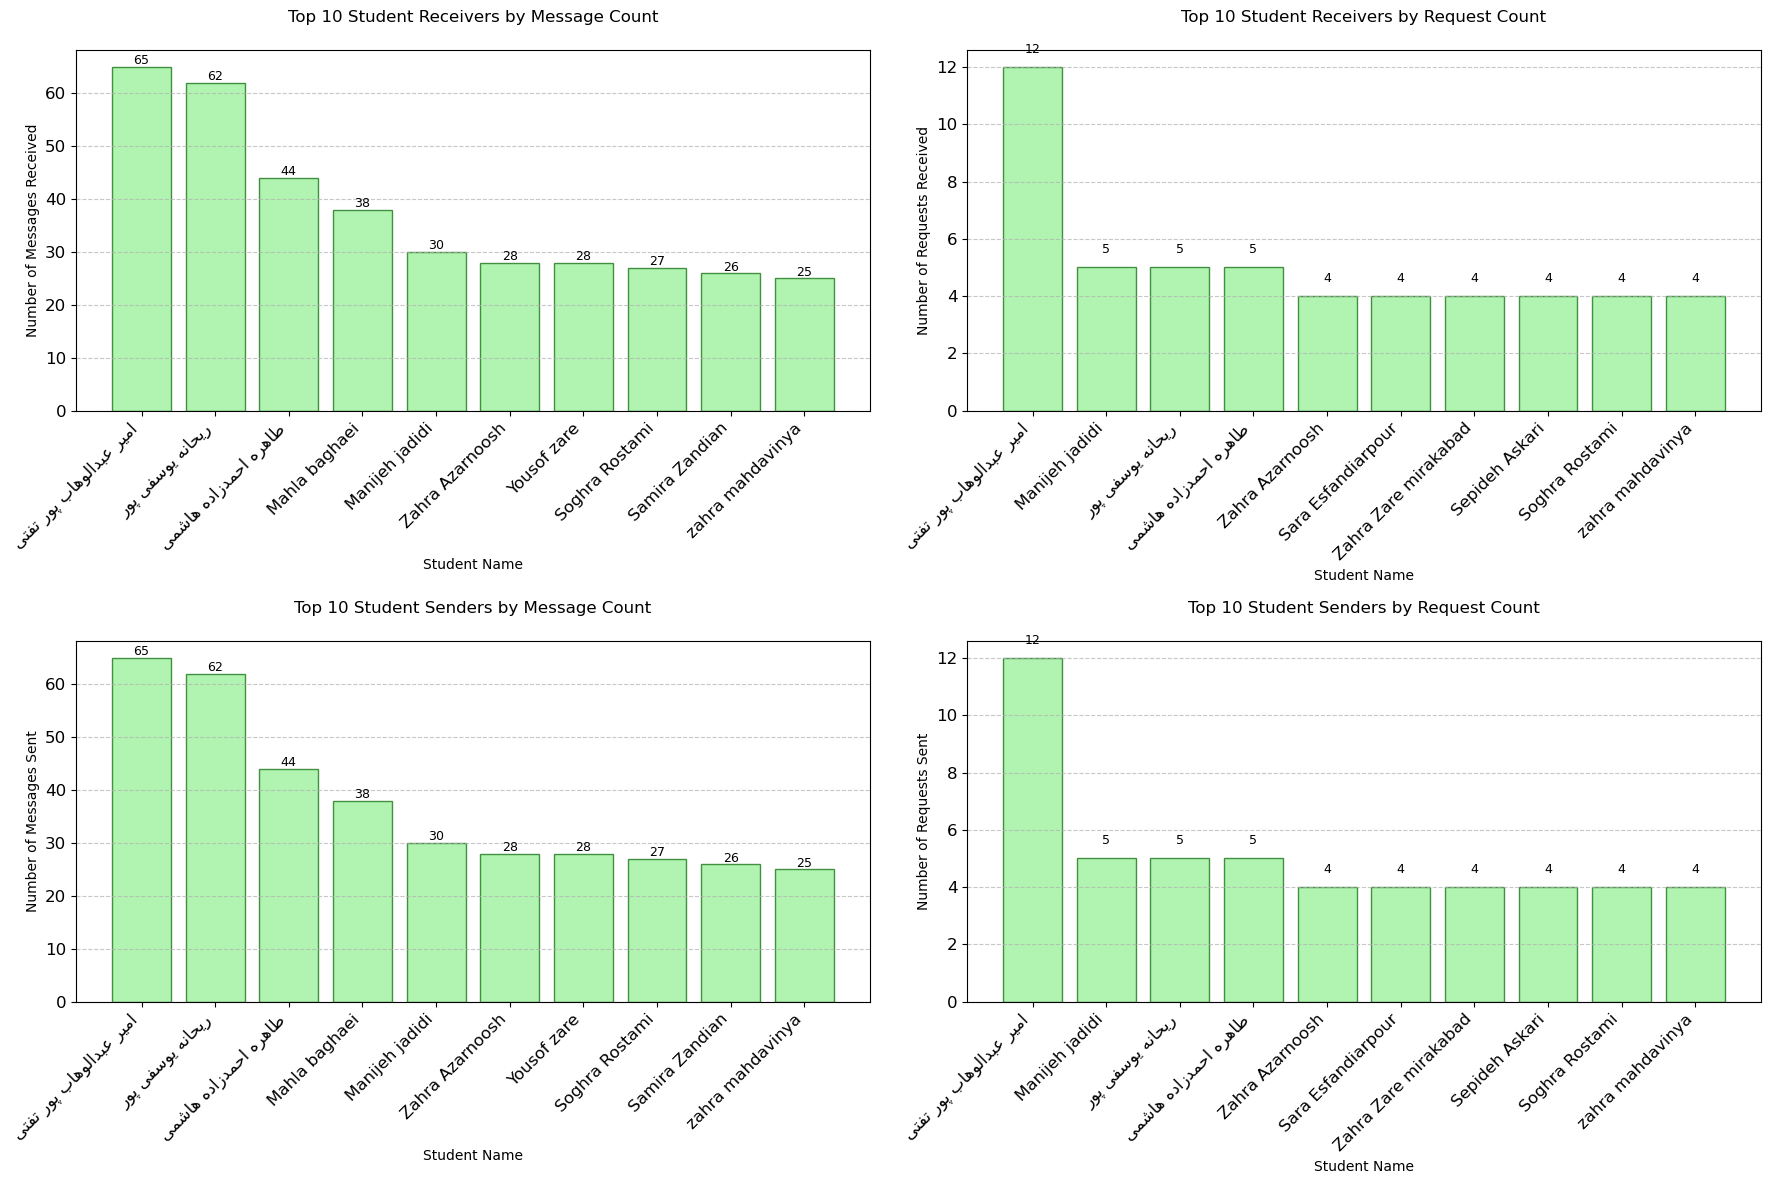

In [7]:
a = analyzer.top_communicators(for_who="student")

522
526


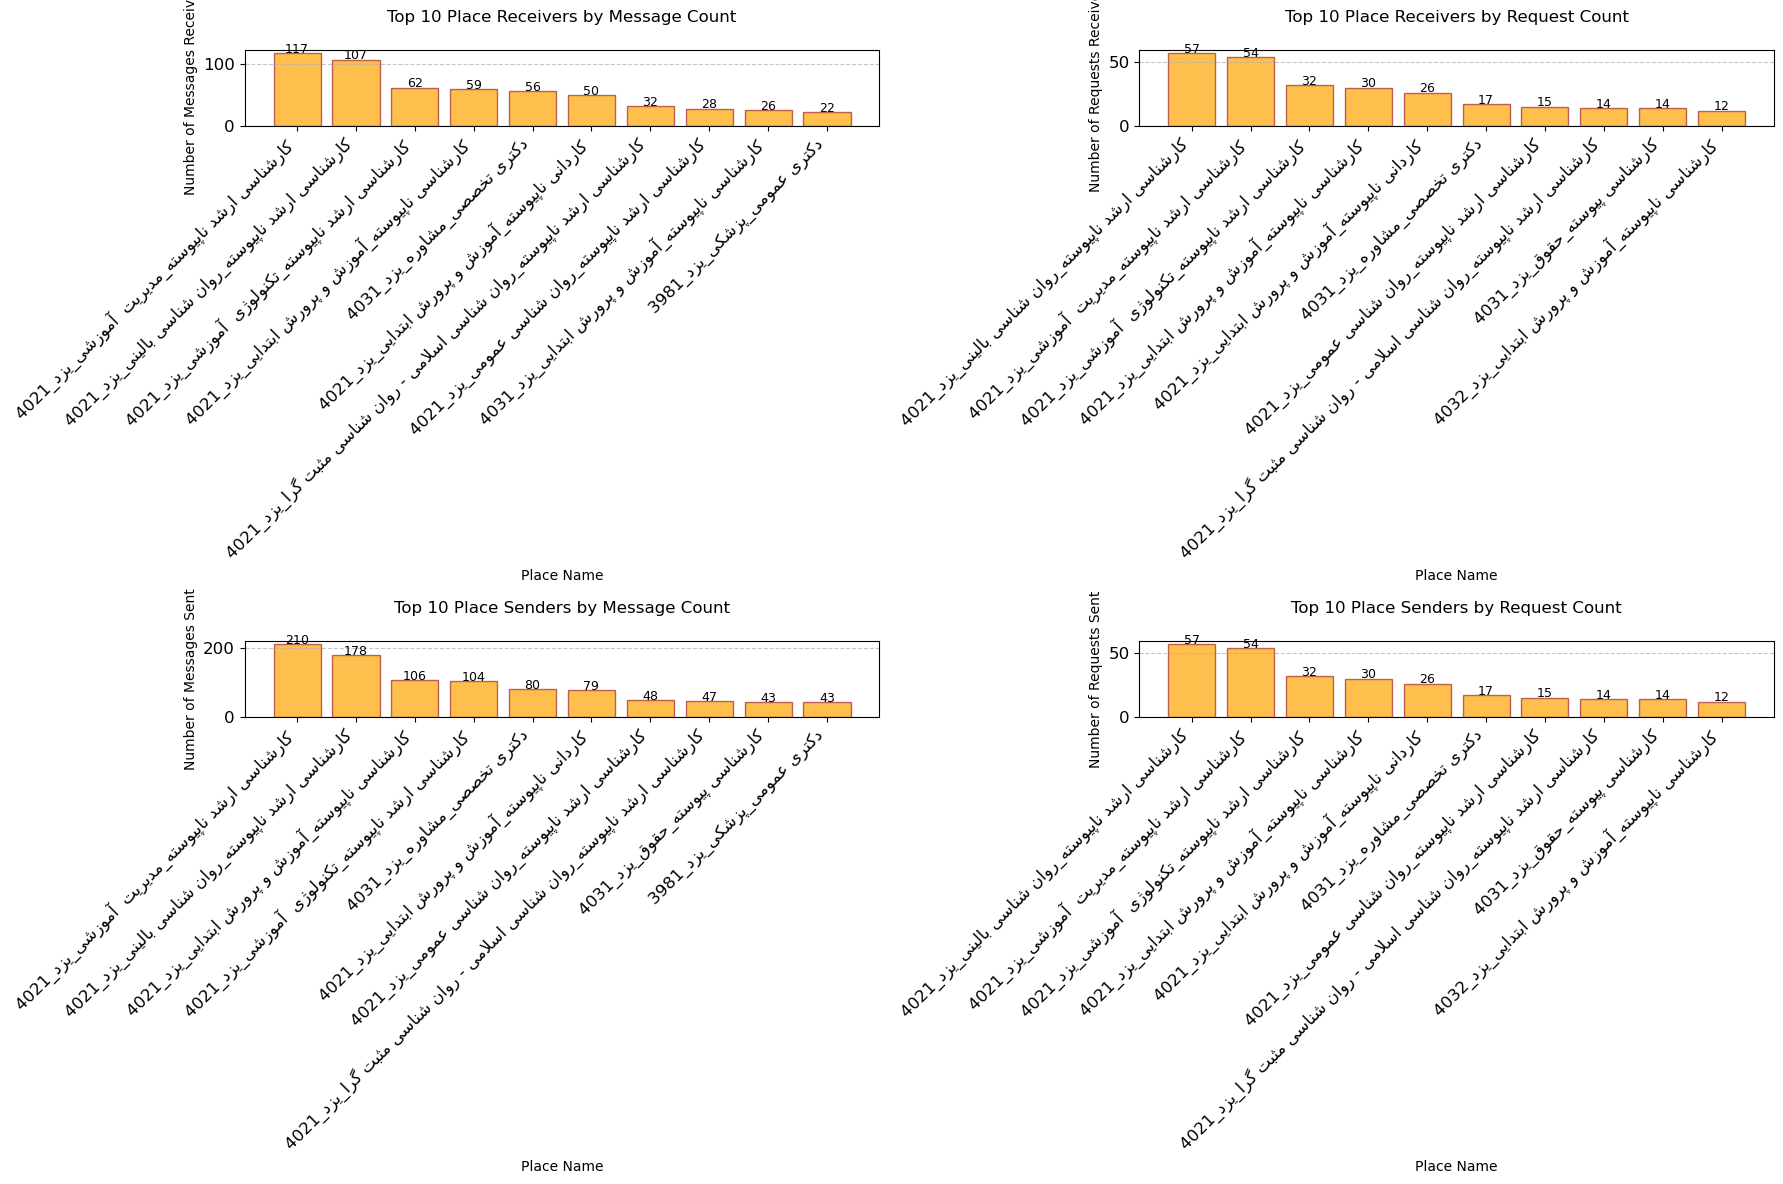

In [8]:
a = analyzer.top_communicators(for_who="place")

522
526


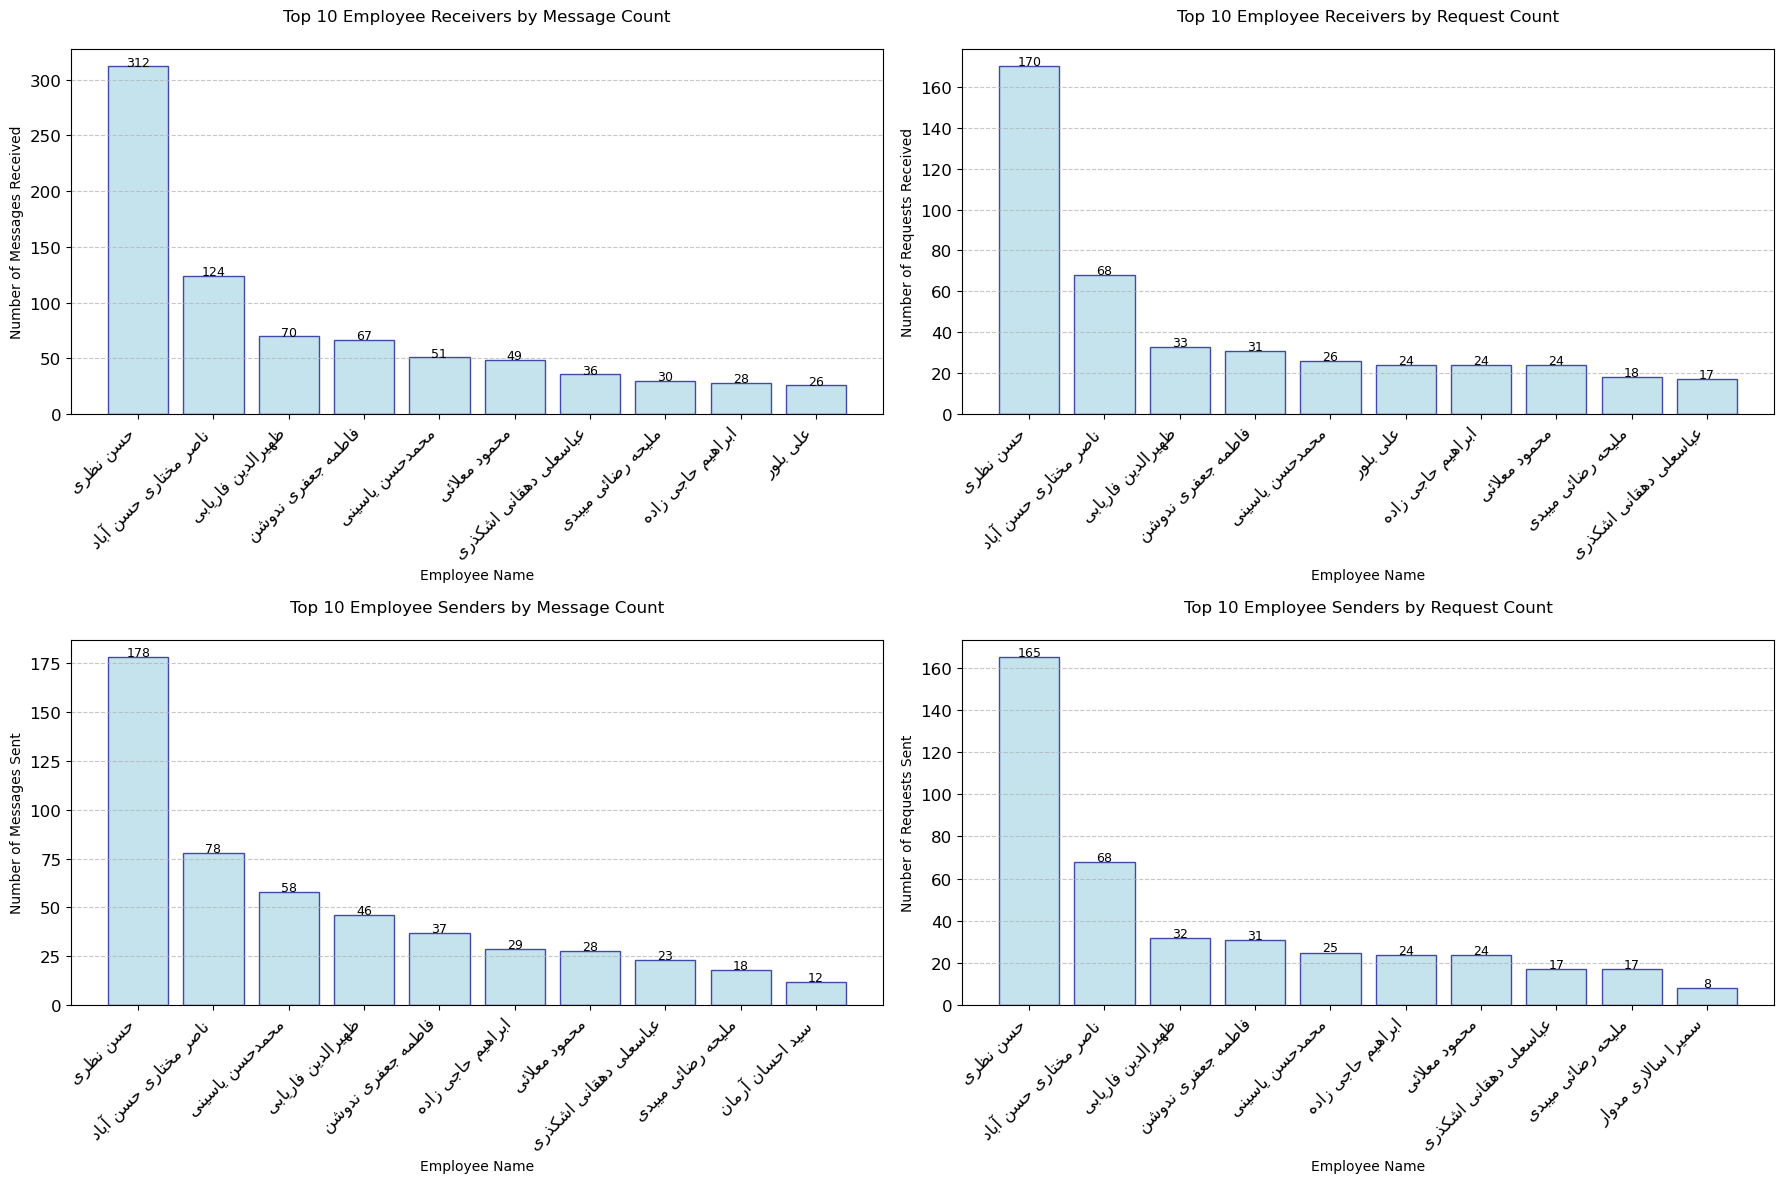

In [9]:
a = analyzer.top_communicators(for_who="employee")

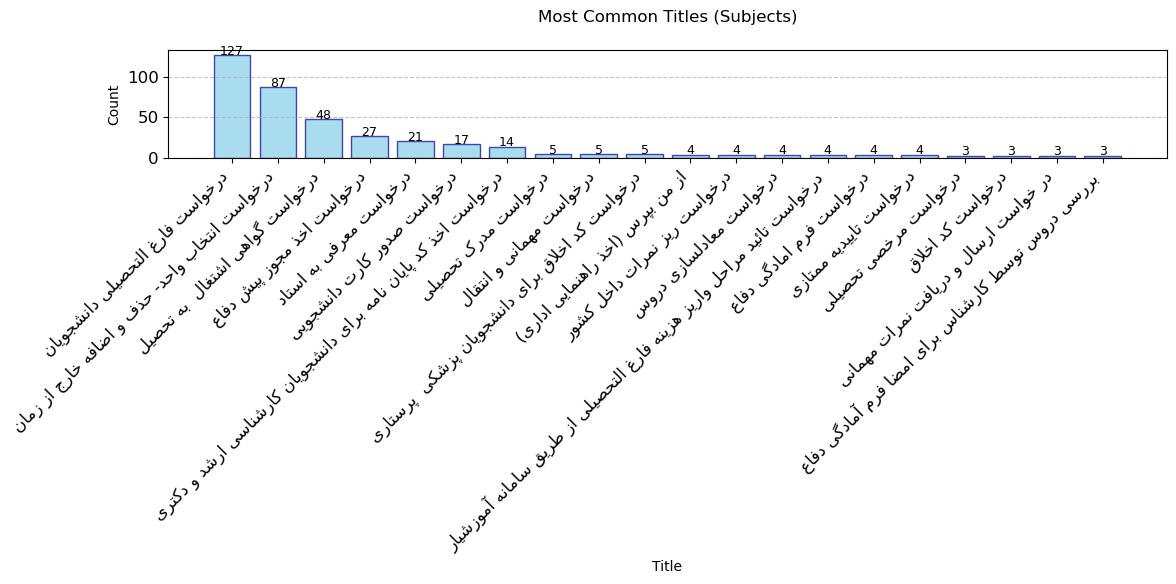

In [10]:
analyzer.common_titles(plot_=True)

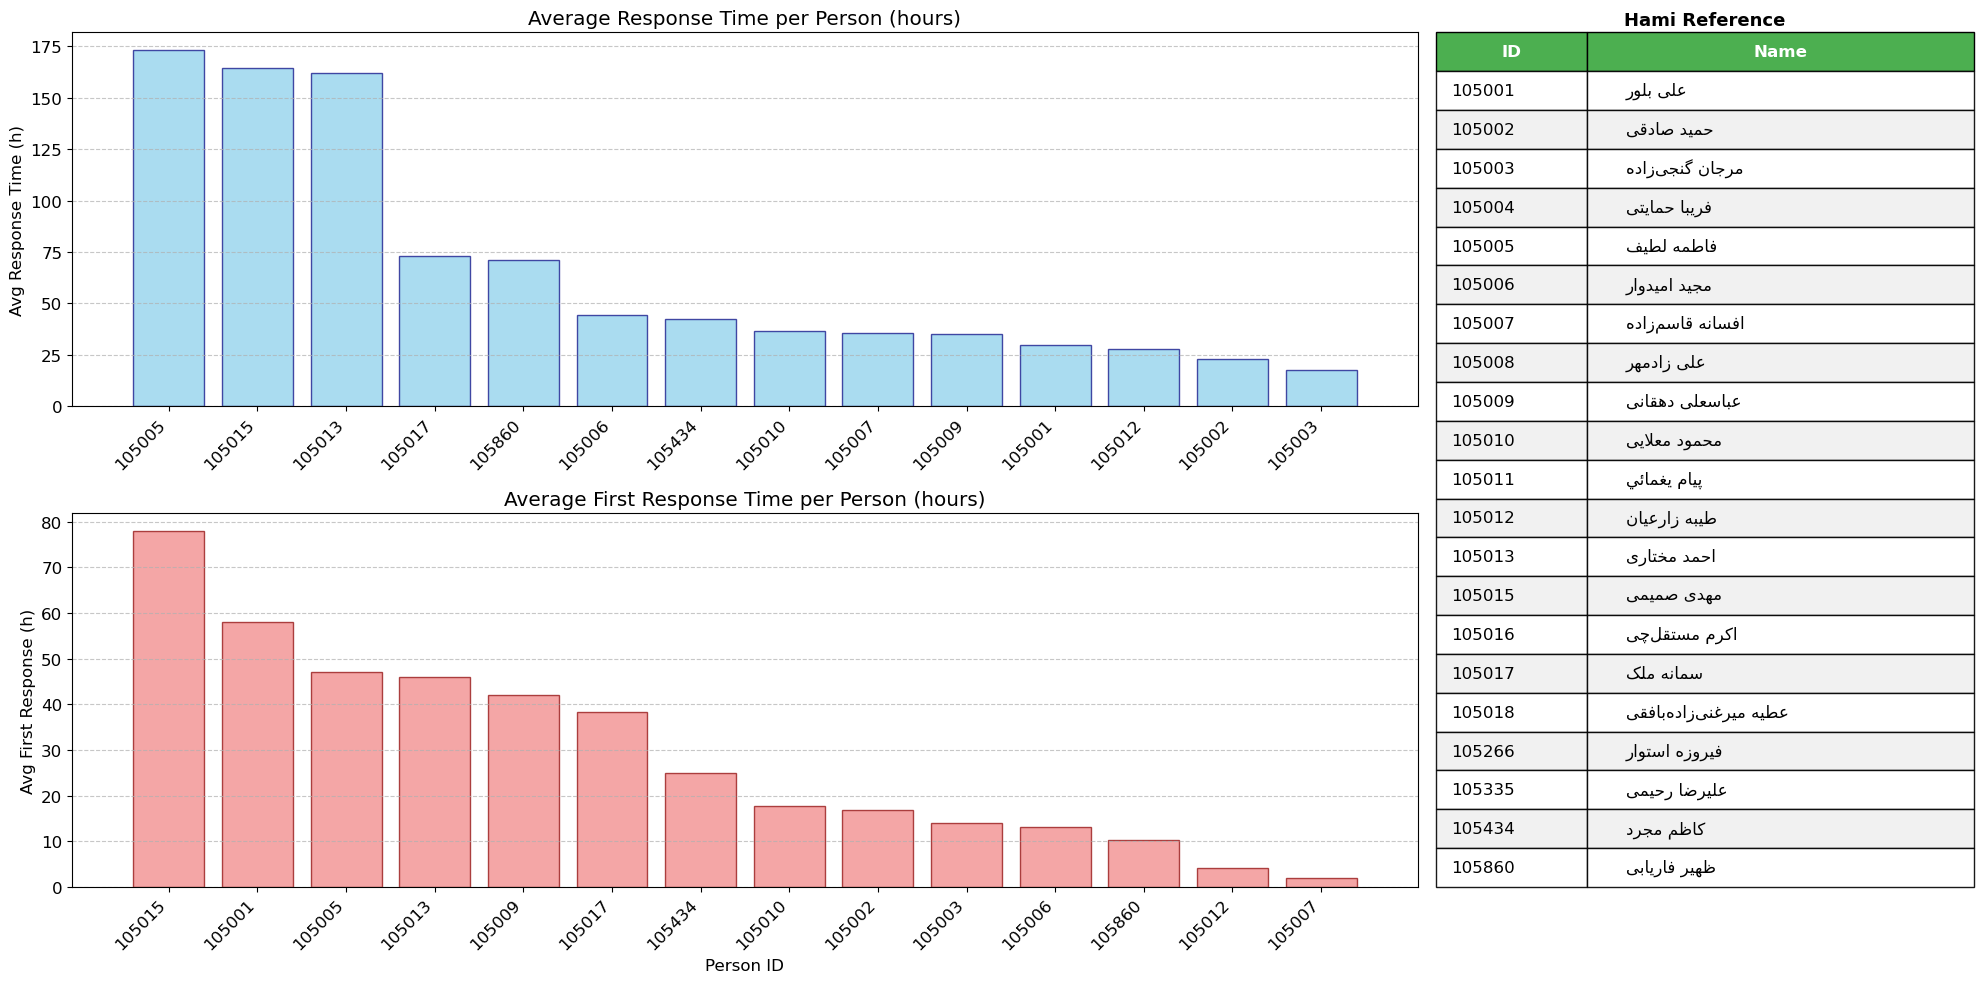

In [11]:
a = analyzer.response_time_per_person(plot=True)

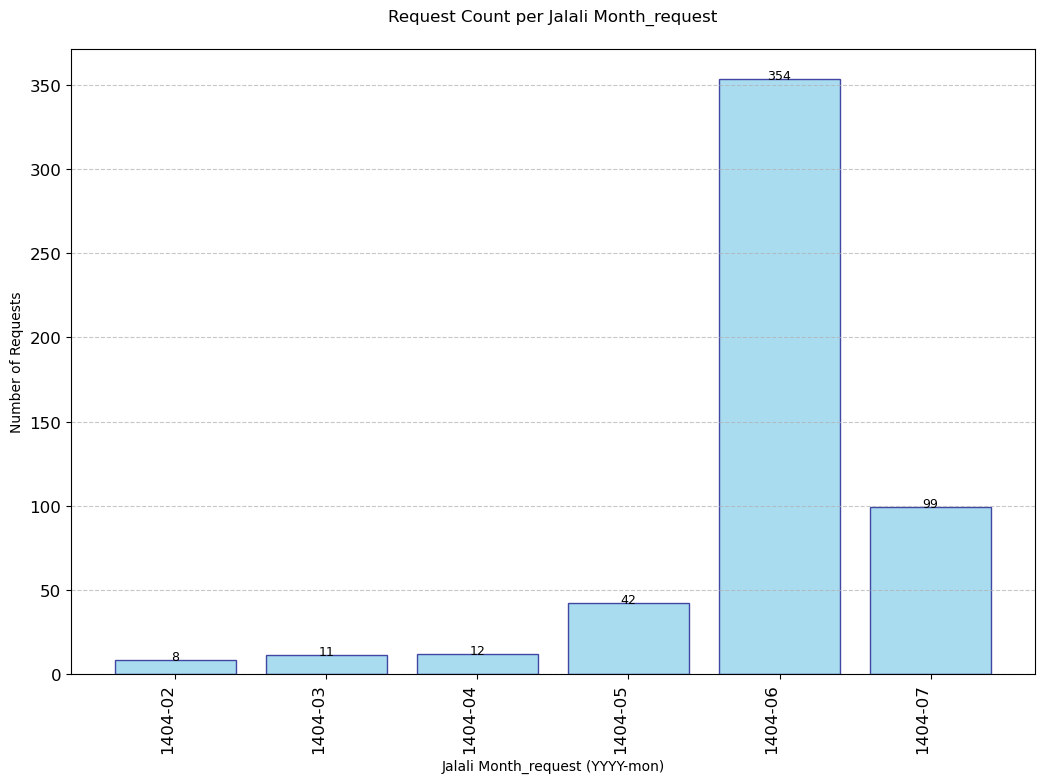

1404-02      8
1404-03     11
1404-04     12
1404-05     42
1404-06    354
1404-07     99
dtype: int64

In [12]:
analyzer.message_date_distribution(plot=True, per="month_request")

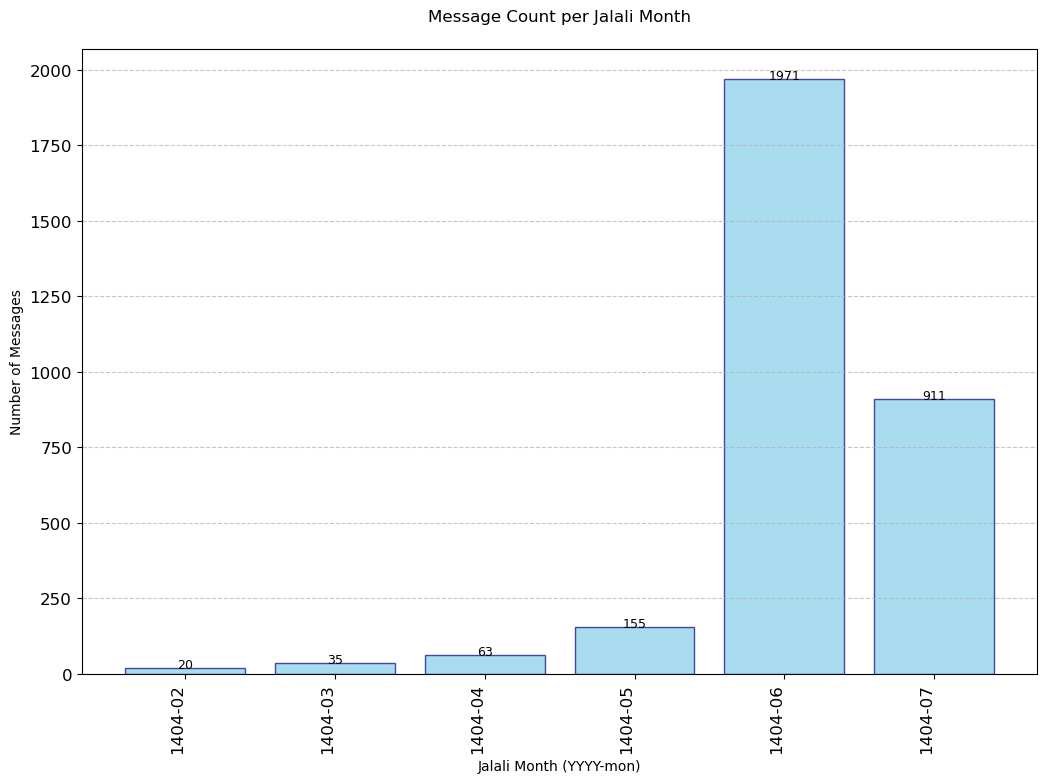

1404-02      20
1404-03      35
1404-04      63
1404-05     155
1404-06    1971
1404-07     911
dtype: int64

In [13]:
analyzer.message_date_distribution(plot=True, per="month")

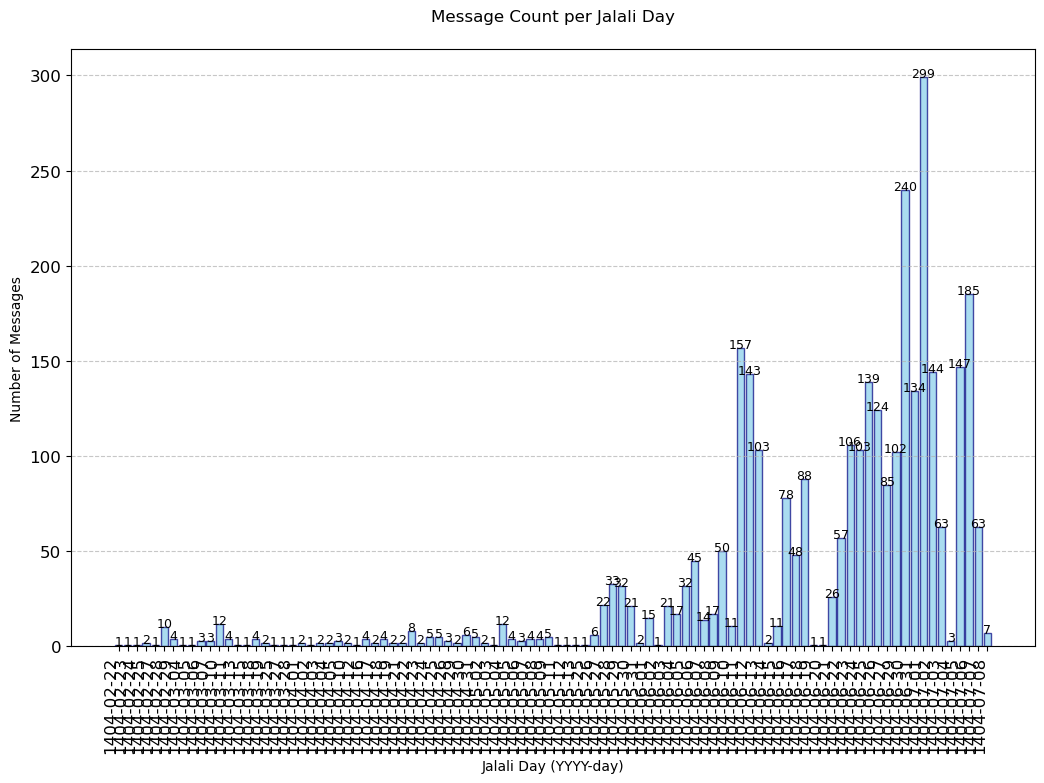

1404-02-22      1
1404-02-23      1
1404-02-24      1
1404-02-25      2
1404-02-27      1
             ... 
1404-07-04      3
1404-07-05    147
1404-07-06    185
1404-07-07     63
1404-07-08      7
Length: 96, dtype: int64

In [14]:
analyzer.message_date_distribution(plot=True, per="day")

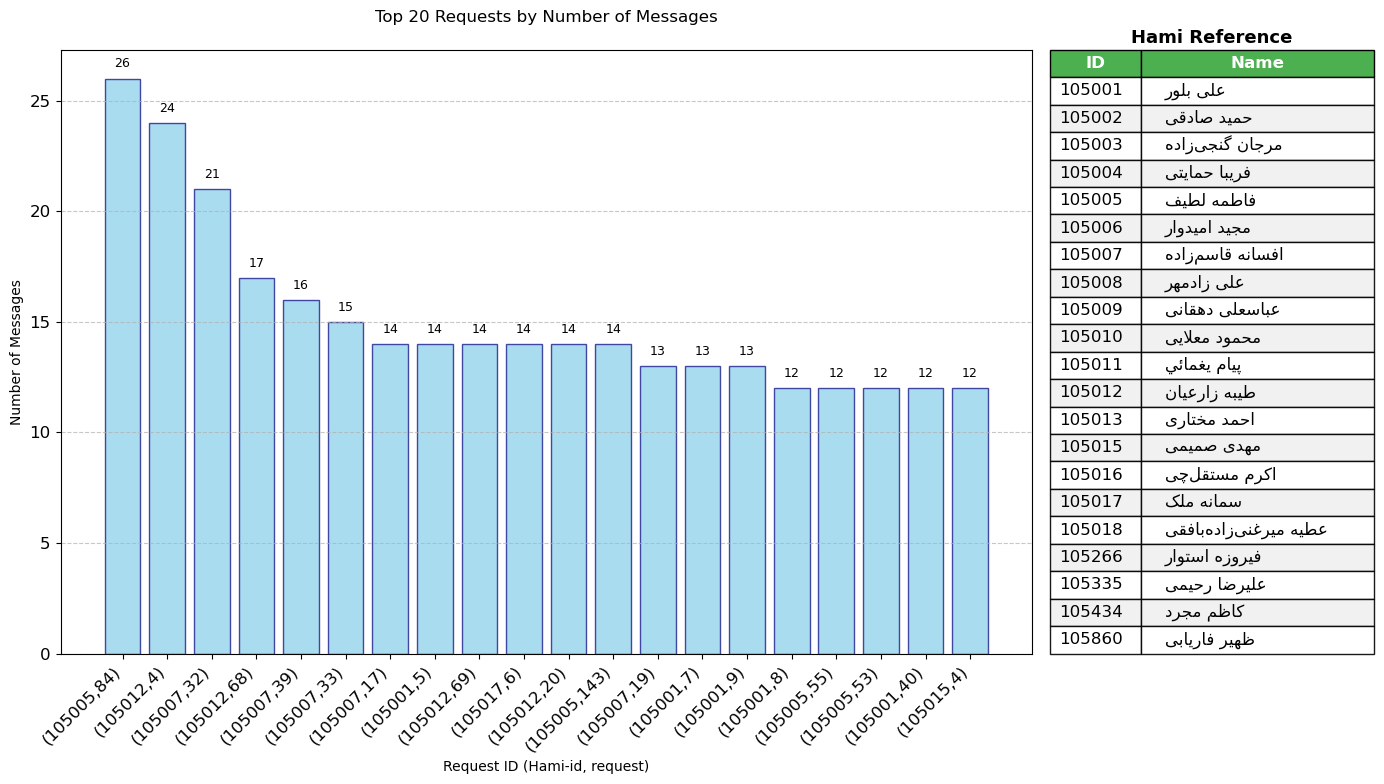

105005  84     26
105012  4      24
105007  32     21
105012  68     17
105007  39     16
               ..
105002  5       3
105012  117     3
105002  7       3
105434  2       3
        1       3
Length: 526, dtype: int64

In [15]:
analyzer.total_messages_per_request(plot=True)

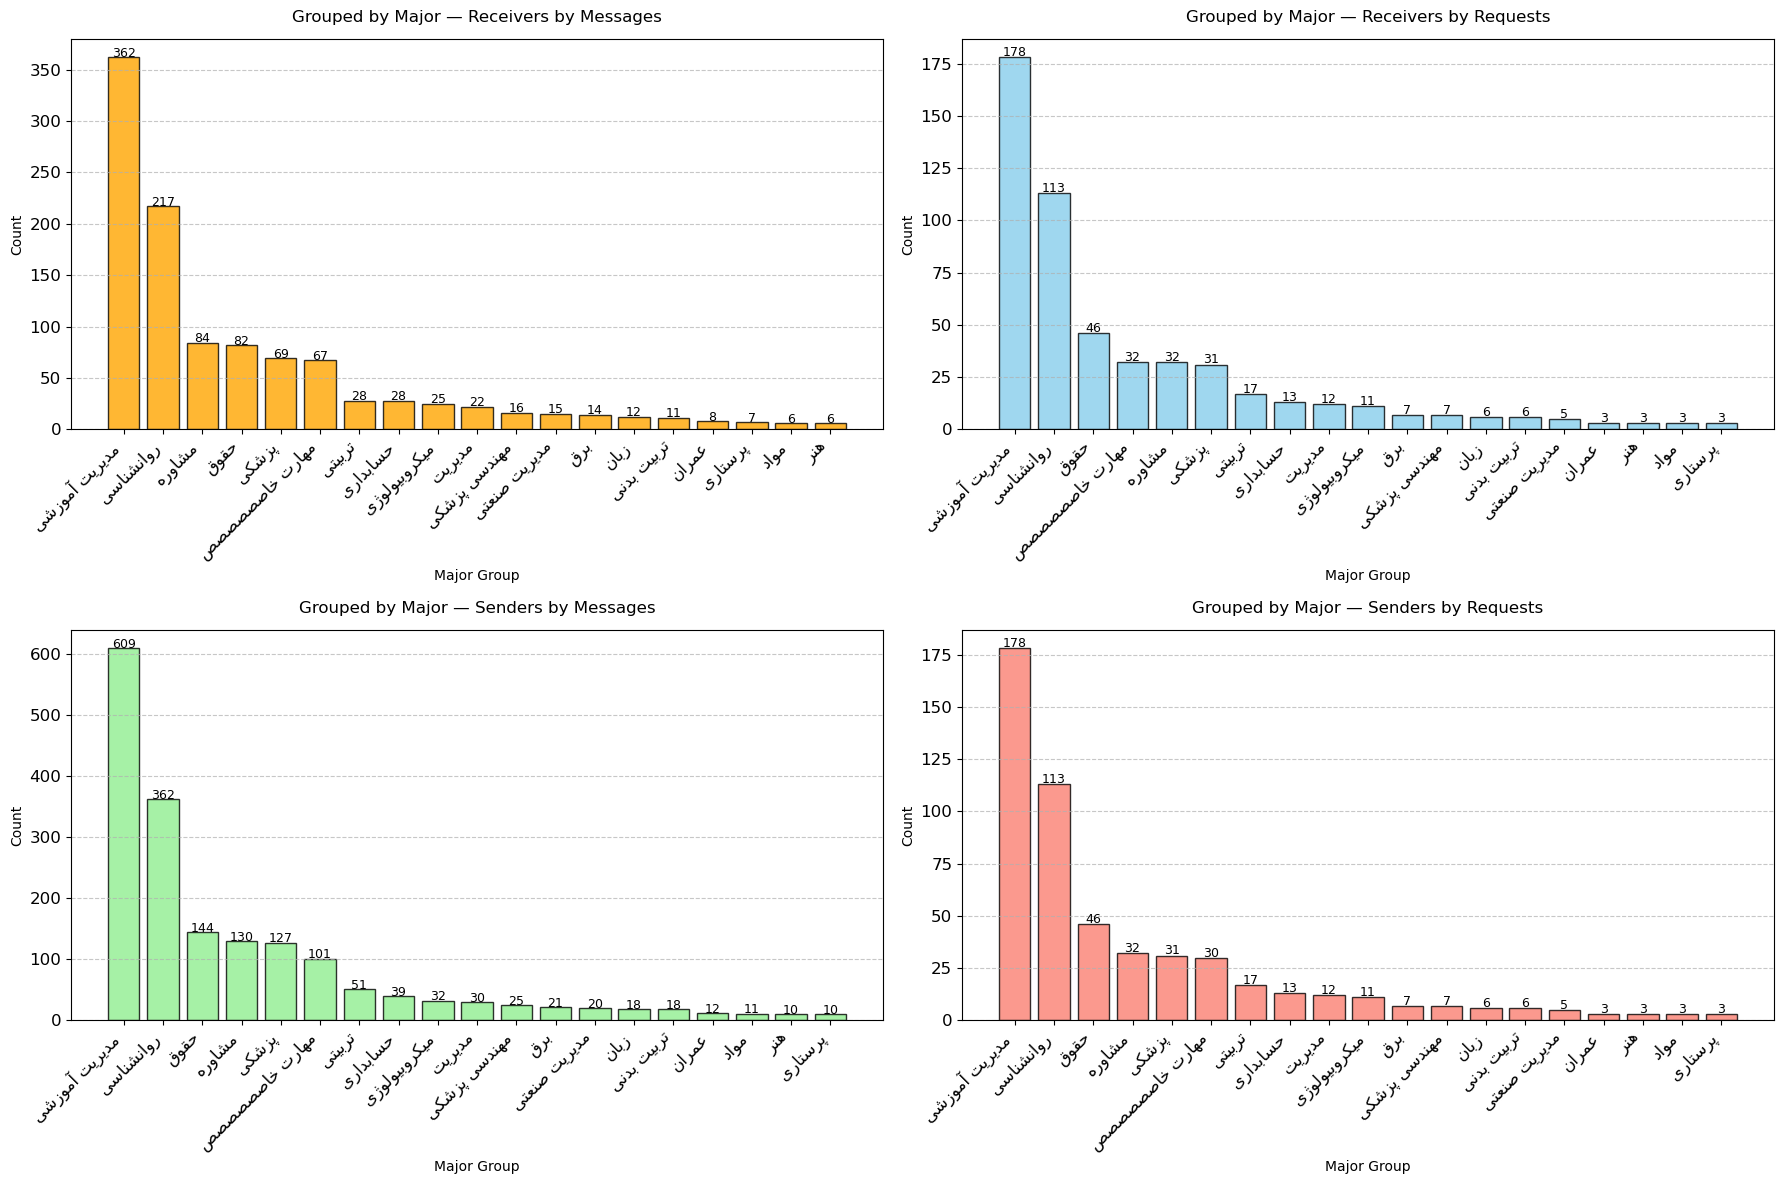

In [90]:
analyzer.place_filtered_by(by="field")

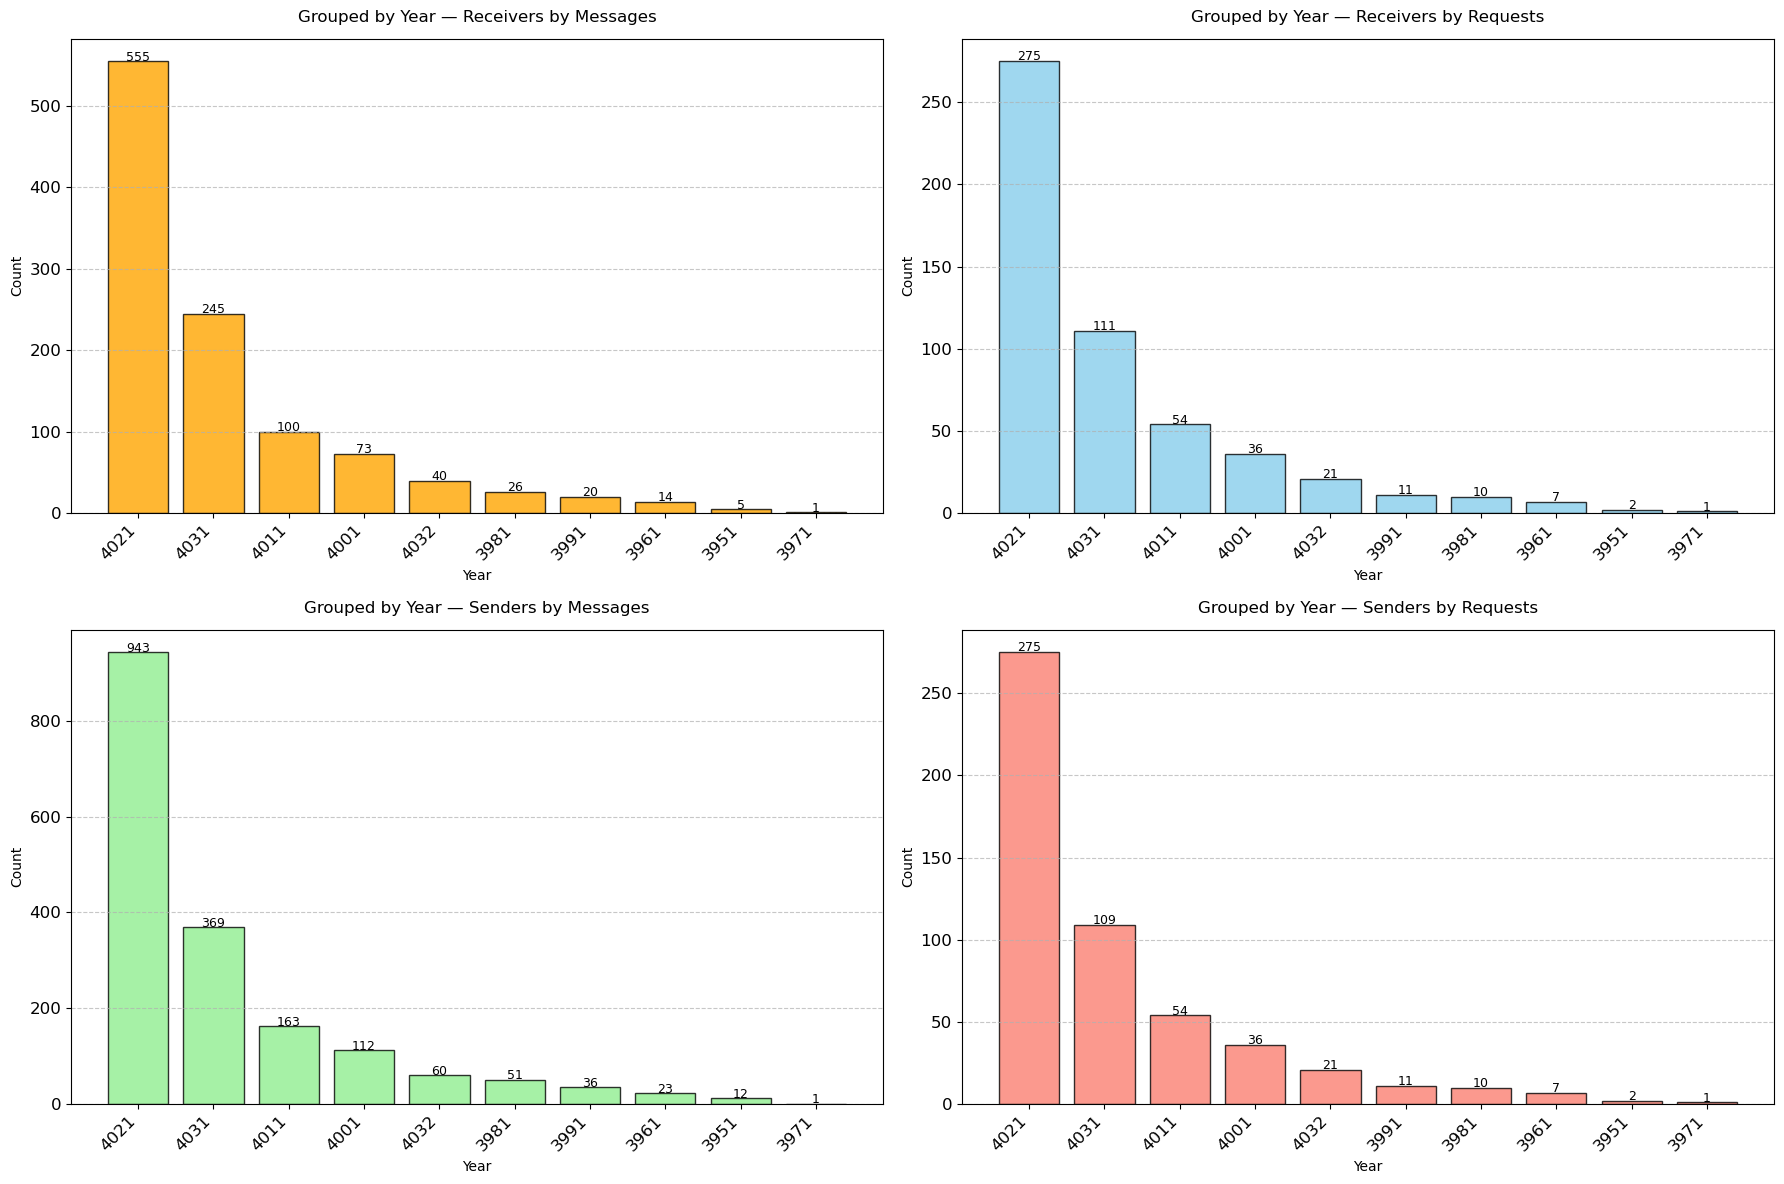

In [91]:
analyzer.place_filtered_by(by="year")

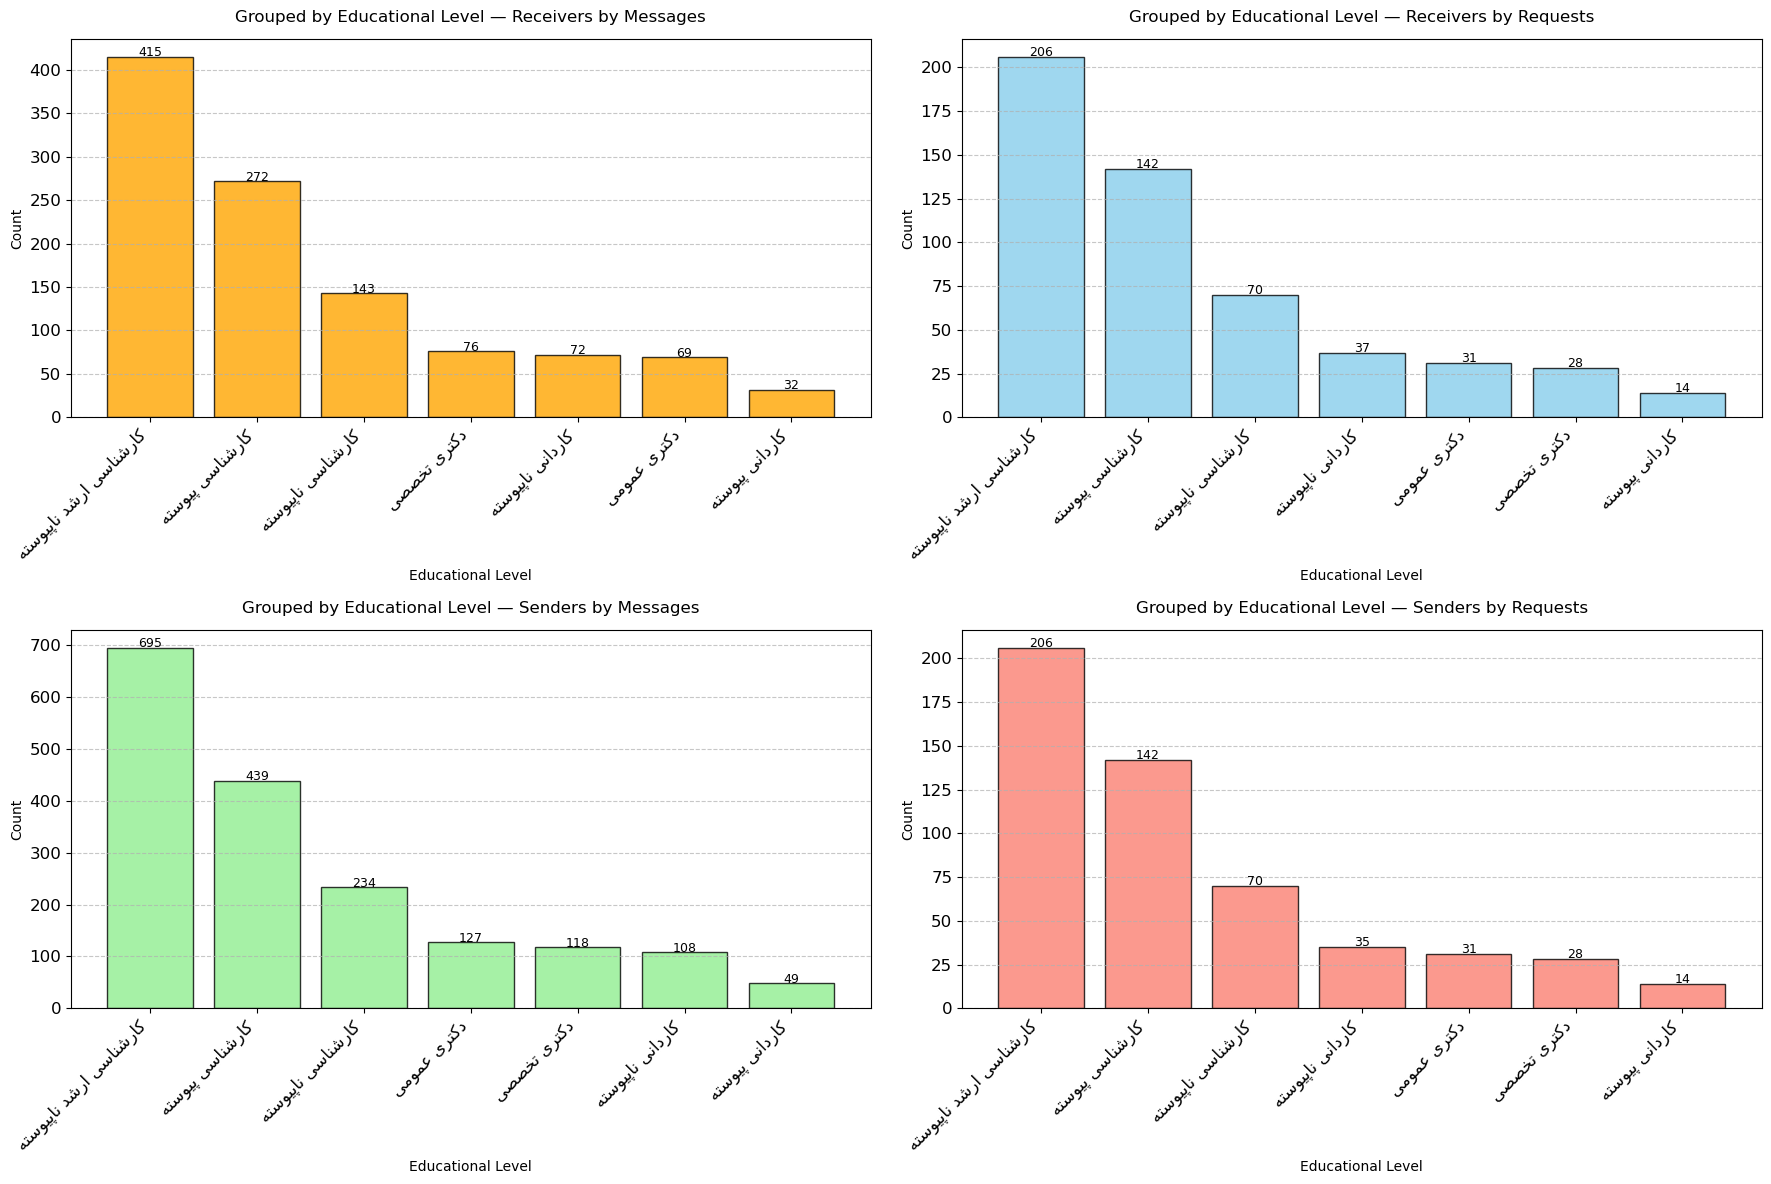

In [92]:
analyzer.place_filtered_by(by="educational_level")

In [18]:
import pandas as pd

a = ["receivers", "senders"]
b = ["messages", "requests"]
for i in a:
    for j in b:
        data = pd.read_csv(f"/mnt/Data1/Python_Projects/Datasets/Hami_Data/output_docs/csv/top_place_{i}_by_{j}.csv")
        data.columns = ["Place", "Count"]
        new_data = pd.DataFrame(columns=["educational_level", "field", "city", "year", "count"])
        for k, v in data.iterrows():
            try:
                if "_" in v["Place"]:
                    dataaa = v["Place"].split("_")
                    if len(dataaa) == 4:
                        educational_level, field, city, year = dataaa
                    elif len(dataaa) == 5:
                        educational_level, field, city, year = dataaa[0], dataaa[1] + "_" + dataaa[2], dataaa[3], dataaa[4]
                else:
                    educational_level, field, city, year = v["Place"].split("-")
                new_data.loc[len(new_data)] = {"educational_level": educational_level, "field": field, "city": city, "year": year, "count": v["Count"]}
            except ValueError:
                print(f"Error processing row {i}: {v['Place']}")

        new_data.to_csv(f"/mnt/Data1/Python_Projects/Datasets/Hami_Data/output_docs/csv/top_place_{i}_by_{j}_expanded.csv", index=False, encoding="utf-8-sig")